## 📘 MILP Benchmark Problem: *enlight8* (MIPLIB 2017)

The **enlight8** instance is a benchmark **binary and integer optimization problem** from the MIPLIB 2017 collection — a widely used repository of mixed-integer programming problems for evaluating solver performance. :contentReference[oaicite:0]{index=0}

Enlight problems (including *enlight8*) originate from a formulation of the combinatorial game **“EnLight”** and were imported from the **MIPLIB 2010 submission set**. The instance has been included in the broader MIPLIB 2017 set and is categorized as an “easy” instance based on solver performance statistics provided by MIPLIB. :contentReference[oaicite:1]{index=1}

---

### 🧮 Problem Structure

The key statistical properties of *enlight8* are as follows: :contentReference[oaicite:2]{index=2}

- **Decision variables**: 128  
- **Binary variables**: 64  
- **General integer variables**: 64  
- **Continuous variables**: 0  
- **Constraints**: 64 linear constraints  
- **Nonzeros**: 352  
- **Status**: easy  
- **Constraint types**: general linear (no special knapsack or cardinality structure in the majority of constraints)  
- **Objective**: linear

This means that *enlight8* is a **pure discrete optimization problem** with no continuous variables — all decisions are either binary or integer. The absence of continuous variables and the relatively modest size make it a suitable case study for solver behavior on classical combinatorial problems. :contentReference[oaicite:3]{index=3}

---

### 🧠 Mathematical Nature

The *enlight8* problem can be generally described as a **pure integer linear programming (ILP)** or **0/1 integer program** with:

- A linear objective function  
- Linear constraints  
- All decision variables restricted to integer values  
- A large proportion of variables being binary (0 or 1)

In a typical formulation:

$$
\begin{aligned}
\min\quad & c^\top x \\
\text{s.t.}\quad & A x \le b \\
& x_j \in \{0,1\} \quad \text{for binary variables} \\
& x_k \in \mathbb{Z} \quad \text{for general integer variables}
\end{aligned}
$$

where:
- \(x\) is the vector of decision variables
- \(c, A, b\) define the objective and constraint data

This type of model arises frequently in combinatorial optimization, scheduling, packaging, and selection problems.

---

### Objective and Known Solution

MIPLIB provides known (benchmark) solutions for certain instances. For *enlight8*, the best known objective value reported on the MIPLIB site is **27**, with no constraint or integrality violations. :contentReference[oaicite:4]{index=4}

If your solution process (using Gurobi) finds a feasible solution with objective 27 and verifies optimality, that confirms alignment with the benchmark standard. If Gurobi proves optimality below or above this value in your run, discuss it in the notebook section on results and solver diagnostics.

---

### Solver Relevance

This instance is particularly useful in optimization teaching or benchmarking because:

- It is **pure integer**, emphasizing discrete decision challenges.
- It contains an equal number of binary and integer variables.
- Its structure reflects typical combinatorial complexity even at modest size.
- It allows visualization of solver progress, such as gap vs time and node exploration.

Comparing solver behavior (objective progression, bound tightening, and gap closure) on *enlight8* versus other instances in your notebook helps illustrate the impact of problem structure on optimization performance.

---

### Source

This problem is part of the MIPLIB 2017 benchmark collection, which contains diverse mixed-integer problems selected for solver evaluation across the optimization research community. :contentReference[oaicite:5]{index=5}


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.8/14.8 MB 77.9 MB/s eta 0:00:00
Restricted license - for non-production use only - expires 2027-11-29
Read MPS format model from file /content/binary_integer_enlight8.mps
Reading time = 0.00 seconds
enlight8: 64 rows, 128 columns, 352 nonzeros
Set parameter OutputFlag to value 1
Gurobi Optimizer version 13.0.0 build v13.0.0rc1 (linux64 - "Ubuntu 22.04.5 LTS")

CPU model: Intel(R) Xeon(R) CPU @ 2.20GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 1 physical cores, 2 logical processors, using up to 2 threads

Optimize a model with 64 rows, 128 columns and 352 nonzeros (Min)
Model fingerprint: 0x937f9c15
Model has 64 linear objective coefficients
Variable types: 0 continuous, 128 integer (0 binary)
Coefficient statistics:
  Matrix range     [1e+00, 2e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+00]
Presolve removed 64 rows and 128 columns
Presolve time: 0.00s
Presolve: All rows and c

/tmp/ipython-input-1914944357.py:61: RuntimeWarning: invalid value encountered in log
  plt.plot(times, np.log(bounds), linestyle="--", label="Best bound")


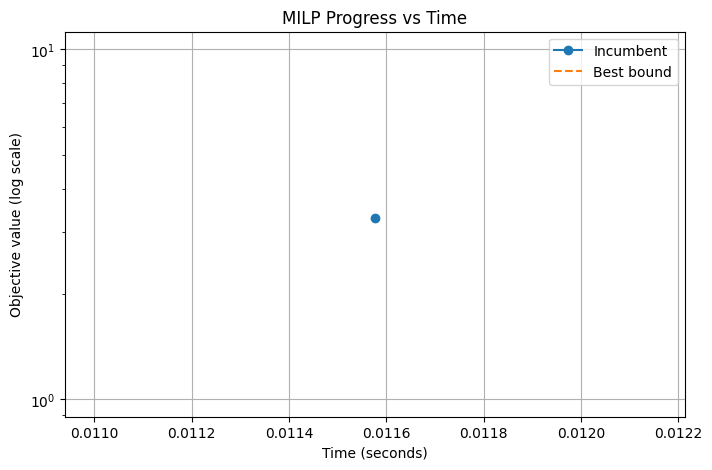

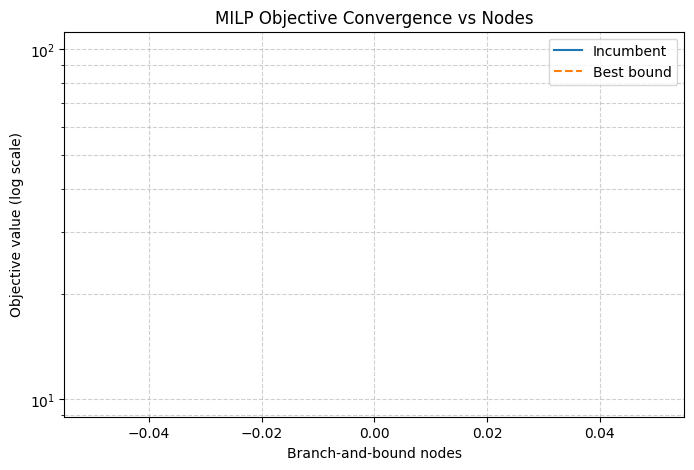

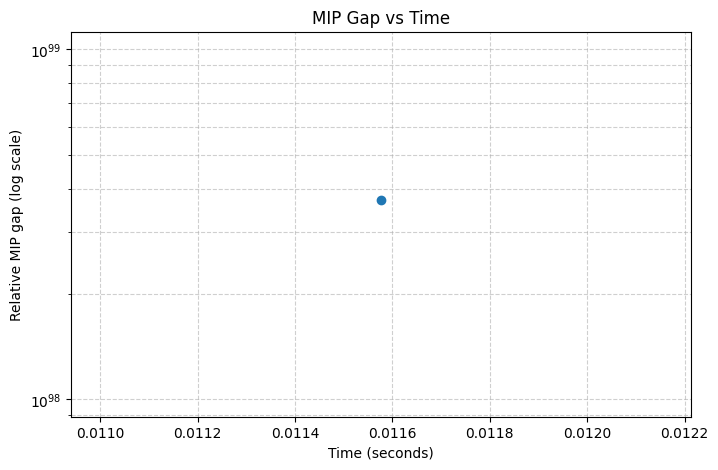

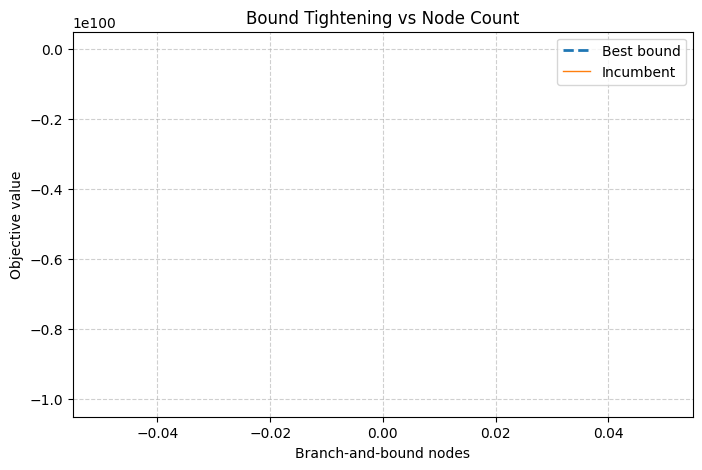

In [1]:
!pip -q install gurobipy

import os
import gurobipy as gp
from gurobipy import GRB
import matplotlib.pyplot as plt
import numpy as np

mps_path = "/content/binary_integer_enlight8.mps"
if not os.path.exists(mps_path):
    raise FileNotFoundError(f"Not found: {mps_path}")

m = gp.read(mps_path)
m.Params.OutputFlag = 1

# --- storage ---
times = []
nodes = []
incumbents = []
bounds = []
events = []

def cb(model, where):
    # Record new feasible solutions (incumbent improvements)
    if where == GRB.Callback.MIPSOL:
        t = model.cbGet(GRB.Callback.RUNTIME)
        n = model.cbGet(GRB.Callback.MIPSOL_NODCNT)
        obj = model.cbGet(GRB.Callback.MIPSOL_OBJ)
        bnd = model.cbGet(GRB.Callback.MIPSOL_OBJBND)

        times.append(t); nodes.append(n)
        incumbents.append(obj); bounds.append(bnd)
        events.append("MIPSOL")

    # Record periodic progress (bound updates)
    elif where == GRB.Callback.MIP:
        t = model.cbGet(GRB.Callback.RUNTIME)
        n = model.cbGet(GRB.Callback.MIP_NODCNT)
        obj_best = model.cbGet(GRB.Callback.MIP_OBJBST)
        obj_bnd  = model.cbGet(GRB.Callback.MIP_OBJBND)

        if obj_best < GRB.INFINITY:
            times.append(t); nodes.append(n)
            incumbents.append(obj_best); bounds.append(obj_bnd)
            events.append("MIP")

# Run once with callback
m.optimize(cb)

print("Collected points:", len(times))
print("Status:", m.Status)
if m.SolCount > 0:
    print("Objective:", m.ObjVal)
    m.write("/content/solution.sol")
    m.write("/content/model_parsed.lp")
    print("Wrote: /content/solution.sol and /content/model_parsed.lp")

# ---- Plot: Objective vs time ----
plt.figure(figsize=(8,5))
plt.plot(times, np.log(incumbents), marker="o", label="Incumbent")
plt.plot(times, np.log(bounds), linestyle="--", label="Best bound")
plt.yscale("log")
plt.xlabel("Time (seconds)")
plt.ylabel("Objective value (log scale)")
plt.title("MILP Progress vs Time")
plt.grid(True)
plt.legend()
plt.show()

# ---- Plot: Objective vs nodes ----
plt.figure(figsize=(8,5))
plt.plot(nodes, incumbents, label="Incumbent")
plt.plot(nodes, bounds, linestyle="--", label="Best bound")

plt.yscale("log")
plt.xlabel("Branch-and-bound nodes")
plt.ylabel("Objective value (log scale)")
plt.title("MILP Objective Convergence vs Nodes")
plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.legend()
plt.show()

# As the search for the optimum advnaces, the integrality gap minimizes.

# Convert to numpy arrays
t = np.asarray(times, dtype=float)
inc = np.asarray(incumbents, dtype=float)
bnd = np.asarray(bounds, dtype=float)

# Safety: keep only finite entries
mask = np.isfinite(t) & np.isfinite(inc) & np.isfinite(bnd)
t, inc, bnd = t[mask], inc[mask], bnd[mask]

# Relative gap for minimization
eps = 1e-12
gap = (inc - bnd) / np.maximum(np.abs(inc), eps)

# Clip to avoid log(0) and negative values due to numerical noise
gap = np.maximum(gap, 1e-12)

# Optional: sort by time (sometimes callback gives non-monotone due to mixed events)
order = np.argsort(t)
t, gap = t[order], gap[order]

plt.figure(figsize=(8,5))
plt.plot(t, gap, marker="o", linewidth=1)
plt.yscale("log")
plt.xlabel("Time (seconds)")
plt.ylabel("Relative MIP gap (log scale)")
plt.title("MIP Gap vs Time")
plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.show()

# plot for Node count vs Best bound (and optional incumbent)
# This plot shows how the lower bound tightens as branch-and-bound explores nodes

n = np.asarray(nodes, dtype=float)
inc = np.asarray(incumbents, dtype=float)
bnd = np.asarray(bounds, dtype=float)

mask = np.isfinite(n) & np.isfinite(inc) & np.isfinite(bnd)
n, inc, bnd = n[mask], inc[mask], bnd[mask]

# Sort by node count
order = np.argsort(n)
n, inc, bnd = n[order], inc[order], bnd[order]

plt.figure(figsize=(8,5))

# Best bound vs nodes (main request)
plt.plot(n, bnd, linestyle="--", linewidth=2, label="Best bound")

# Optional: include incumbent for context
plt.plot(n, inc, linewidth=1, label="Incumbent")

plt.xlabel("Branch-and-bound nodes")
plt.ylabel("Objective value")
plt.title("Bound Tightening vs Node Count")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.show()


### Solver behavior: solved during presolve (no B&B search)

For the *enlight8* instance, Gurobi solved the problem entirely during **presolve**.  
The original model contained **64 constraints**, **128 integer variables**, and **352 nonzeros**.  
During presolve, Gurobi eliminated all rows and columns:

- `Presolve removed 64 rows and 128 columns`
- `Presolve: All rows and columns removed`

As a result, no branch-and-bound search was required:

- Nodes explored: **0**
- Simplex iterations: **0**

Gurobi directly returned an optimal solution with objective value:

\[
\boxed{z^* = 27}
\]

Since the best bound equals the incumbent objective, the optimality gap is **0%**, confirming that the solution is provably optimal.
